# Patent SAR Miner — validation and SAR review
This notebook reads an existing CLI result directory. It performs no network access and does not modify the source CSV.


In [6]:
from pathlib import Path
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw, rdmolfiles
from patent_sar_miner.visualization import cluster_counts, draw_bar, load_results, scaffold_counts, year_stack_counts

RESULTS_DIR = Path('../example_results')
if not RESULTS_DIR.is_dir() and Path('../results').is_dir():
    RESULTS_DIR = Path('../results')
data = load_results(RESULTS_DIR)
manifest = data['run_manifest']
analysis_column = manifest.get('input', {}).get('analysis_column', 'analysis value')
activities = data['all_activities']
compounds = data['standardized_compounds']
print('Loaded:', data['directory'])
print('Selected structure column:', manifest.get('input', {}).get('structure_column'))
print('Selected analysis column:', analysis_column)


Loaded: /Users/crisslind/Documents/toolshed/patent-sar-miner_v0.2/example_results
Selected structure column: smiles
Selected analysis column: pIC50


## Measurement quality and uncertainty


,analysis_column,total_records,usable_exact_records,censored_or_approximate_records,non_numeric_or_missing_records,unique_standardized_structures,structures_with_replicates,replicate_disagreement_threshold,structures_with_replicate_disagreement
0,pIC50,240,224,16,0,216,21,1.0,0


,records
measurement_qc_flag,
usable_exact_value,224
censored_or_approximate,16


,standardized_smiles,compound_id,n_measurements,mean,median,std,mad,minimum,maximum,range,ci95_lower,ci95_upper,replicate_disagreement,source_rows
3,Brc1ccc(N2CCOCC2)cc1,DPC0059,2,5.890,5.890,0.084853,0.060,5.83,5.95,0.12,5.7724,6.0076,False,59 | 221
6,CCCc1ccc(C(=O)NC)cc1,DPC0110,2,5.930,5.930,0.070711,0.050,5.88,5.98,0.10,5.8320,6.0280,False,110 | 224
9,CCCc1ccc(C(N)=O)cc1,DPC0109,2,5.820,5.820,0.169706,0.120,5.70,5.94,0.24,5.5848,6.0552,False,109 | 223
11,CCCc1ccc(C2CC2)cc1,DPC0114,2,5.905,5.905,0.219203,0.155,5.75,6.06,0.31,5.6012,6.2088,False,114 | 228
15,CCCc1ccc(F)cc1,DPC0006,2,5.565,5.565,0.459619,0.325,5.24,5.89,0.65,4.9280,6.2020,False,6 | 240
18,CCCc1ccc(N2CCOCC2)cc1,DPC0113,2,6.240,6.240,0.141421,0.100,6.14,6.34,0.20,6.0440,6.4360,False,113 | 227
21,CCCc1ccc(OC(F)(F)F)cc1,DPC0112,2,6.000,6.000,0.056569,0.040,5.96,6.04,0.08,5.9216,6.0784,False,112 | 226
53,CCc1ccc(F)cc1,DPC0005,2,5.630,5.630,0.339411,0.240,5.39,5.87,0.48,5.1596,6.1004,False,5 | 239
75,CNC(=O)c1ccc(Br)cc1,DPC0056,2,5.940,5.940,0.056569,0.040,5.90,5.98,0.08,5.8616,6.0184,False,56 | 218
84,CNC(=O)c1ccc(NC)cc1,DPC0168,2,6.430,6.430,0.084853,0.060,6.37,6.49,0.12,6.3124,6.5476,False,168 | 234


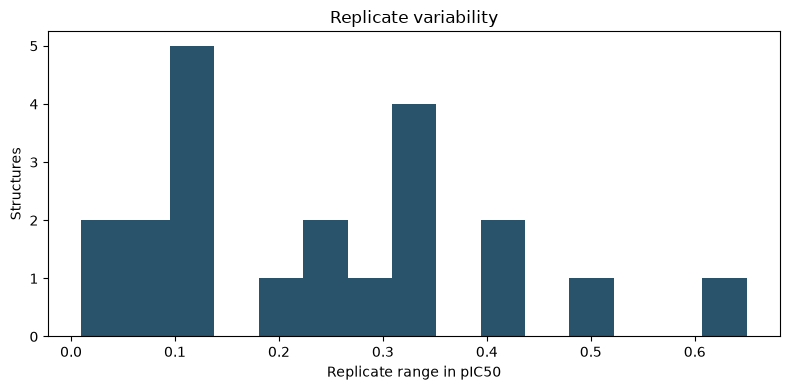

In [7]:
quality = data['measurement_qc']
replicates = data['replicate_summary']
display(pd.DataFrame([data['uncertainty_summary']]))
if not quality.empty and 'measurement_qc_flag' in quality.columns:
    display(quality['measurement_qc_flag'].value_counts().to_frame('records'))
if not replicates.empty:
    display(replicates.sort_values(['replicate_disagreement', 'n_measurements'], ascending=False).head(30))
    repeated = replicates.loc[replicates['n_measurements'] > 1]
    if not repeated.empty:
        fig, ax = plt.subplots(figsize=(8, 4))
        repeated['range'].plot.hist(ax=ax, bins=min(15, max(3, len(repeated))), color='#28536b')
        ax.set(xlabel=f'Replicate range in {analysis_column}', ylabel='Structures', title='Replicate variability')
        fig.tight_layout()
        plt.show()


## Predictive validation
The primary estimate is the scaffold-group holdout. Prediction intervals use cross-validated training residuals.


,status,analysis_column,algorithm,split,random_seed,n_compounds,n_scaffolds,conformal_coverage_target,conformal_radius,mean_baseline_mae,holdout_metrics.n,holdout_metrics.mae,holdout_metrics.rmse,holdout_metrics.r2,holdout_metrics.spearman,leave_one_patent_out_metrics.n,leave_one_patent_out_metrics.mae,leave_one_patent_out_metrics.rmse,leave_one_patent_out_metrics.r2,leave_one_patent_out_metrics.spearman
0,completed,pIC50,RandomForestRegressor on radius-2 Morgan finge...,deterministic scaffold-group holdout nearest 25%,42,203,4,0.9,0.413567,0.320147,14,0.277609,0.322199,-0.639407,0.718681,203,0.305898,0.376663,-0.378684,0.138575


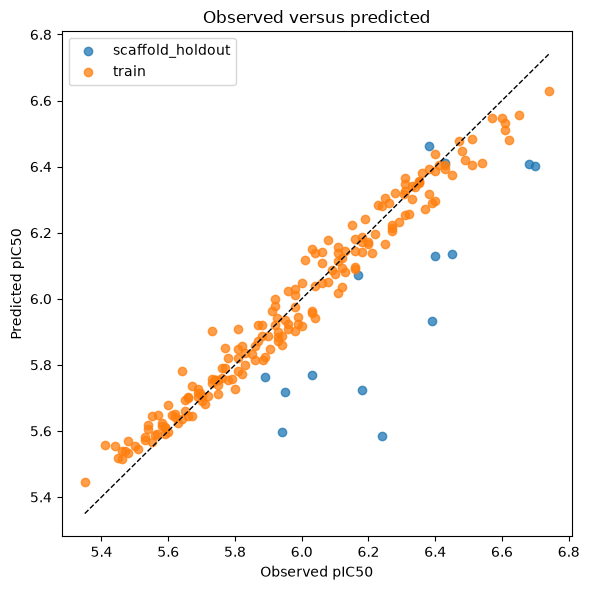

In [8]:
model_summary = data['model_validation']
predictions = data['model_predictions']
display(pd.json_normalize(model_summary))
if not predictions.empty:
    fig, ax = plt.subplots(figsize=(6, 6))
    for label, group in predictions.groupby('split'):
        ax.scatter(group['observed'], group['predicted'], alpha=0.75, label=label)
    limits = [min(predictions['observed'].min(), predictions['predicted'].min()), max(predictions['observed'].max(), predictions['predicted'].max())]
    ax.plot(limits, limits, '--', color='black', linewidth=1)
    ax.set(xlabel=f'Observed {analysis_column}', ylabel=f'Predicted {analysis_column}', title='Observed versus predicted')
    ax.legend()
    fig.tight_layout()
    plt.show()


## Chemical series and dataset composition


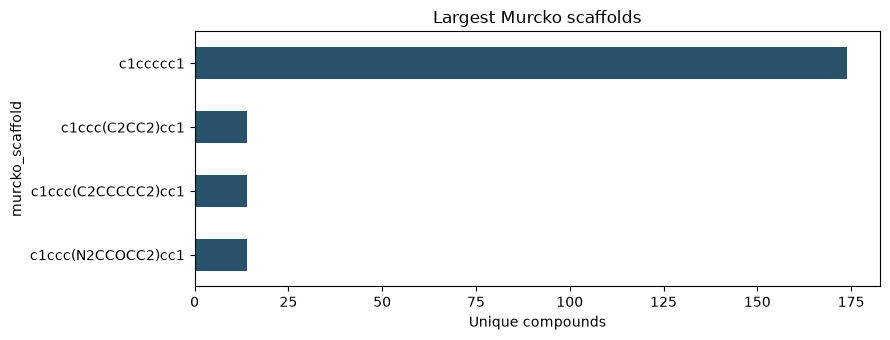

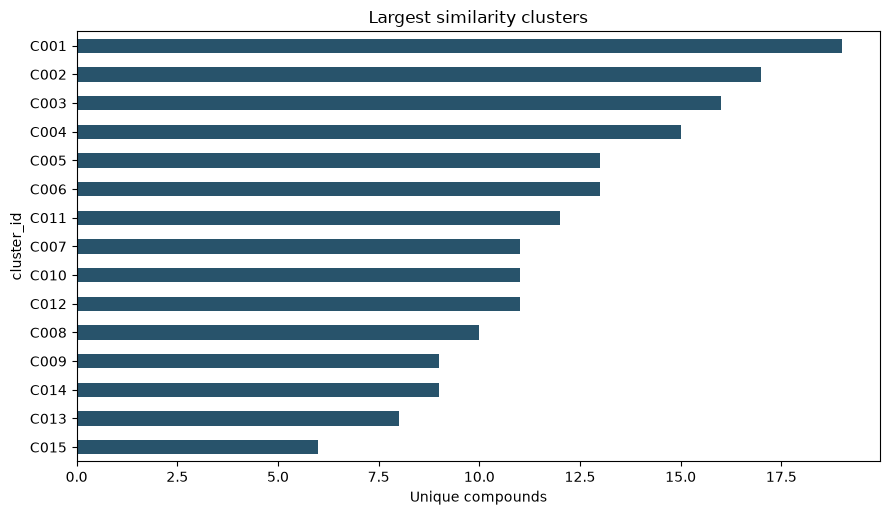

stack,Helixbridge Pharma,Kestrel BioDiscovery,Mosaic Medicines,Northstar Therapeutics
publication_year,,,,
2022,60,0,0,60
2023,0,60,0,0
2024,0,0,60,0


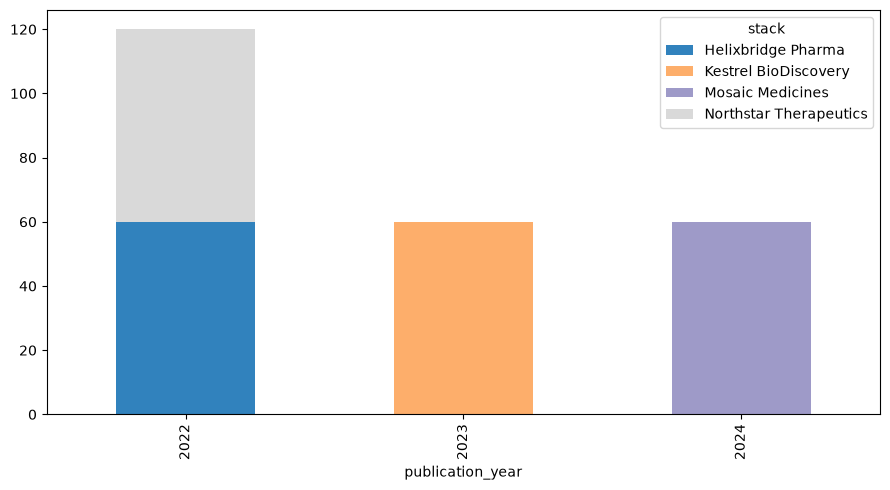

,compound_id,smiles,patent_id,assignee,publication_date,year,series,assay_id,standard_relation,pIC50,...,hbd,hba,rotatable_bonds,heavy_atoms,rings,pIC50_median,n_measurements,murcko_scaffold,scaffold_id,cluster_id
0,DPC0001,Fc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-02,=,5.54,...,0,0,0,8,1,5.750,2.0,c1ccccc1,S001,C020
1,DPC0002,Fc1ccc(Cl)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-03,=,5.72,...,0,0,0,8,1,5.885,2.0,c1ccccc1,S001,C019
2,DPC0003,Fc1ccc(Br)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-04,=,5.64,...,0,0,0,8,1,5.790,2.0,c1ccccc1,S001,C018
3,DPC0004,Cc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-05,=,5.45,...,0,0,0,8,1,5.620,2.0,c1ccccc1,S001,C017
4,DPC0005,CCc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-06,=,5.39,...,0,0,1,9,1,5.630,2.0,c1ccccc1,S001,C005
5,DPC0006,CCCc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-07,=,5.24,...,0,0,2,10,1,5.565,2.0,c1ccccc1,S001,C002
6,DPC0007,COc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-08,=,5.35,...,0,1,1,9,1,5.350,1.0,c1ccccc1,S001,C004
7,DPC0008,CCOc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-09,=,5.47,...,0,1,2,10,1,5.470,1.0,c1ccccc1,S001,C001
8,DPC0009,Nc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-10,=,5.48,...,1,1,0,8,1,5.480,1.0,c1ccccc1,S001,C015
9,DPC0010,CNc1ccc(F)cc1,DEMO-101-A1,Northstar Therapeutics,2022-03-17,2022,phenyl,ASSAY-01-11,=,5.65,...,1,1,1,9,1,5.650,1.0,c1ccccc1,S001,C008


In [9]:
draw_bar(scaffold_counts(compounds), 'Largest Murcko scaffolds', 'Unique compounds')
draw_bar(cluster_counts(compounds).head(15), 'Largest similarity clusters', 'Unique compounds')
associations = data['patent_compound_associations']
source = associations if not associations.empty else data['standardized_records']
year_counts = year_stack_counts(source, by='auto')
if not year_counts.empty:
    display(year_counts)
    year_counts.plot.bar(stacked=True, figsize=(9, 5), colormap='tab20c')
    plt.tight_layout()
    plt.show()
display(compounds.head(15))


## Matched pairs and R groups


Hydrogen-only R groups omitted: none


,compound_a,compound_b,shared_core,fragment_a,fragment_b,assignees_a,assignees_b,pIC50_median_a,pIC50_median_b,activity_delta_b_minus_a
0,DPC0001,DPC0002,,,,Mosaic Medicines | Northstar Therapeutics,Mosaic Medicines | Northstar Therapeutics,5.750000,5.885000,0.135000
1,DPC0001,DPC0003,,,,Mosaic Medicines | Northstar Therapeutics,Mosaic Medicines | Northstar Therapeutics,5.750000,5.790000,0.040000
2,DPC0001,DPC0004,,,,Mosaic Medicines | Northstar Therapeutics,Mosaic Medicines | Northstar Therapeutics,5.750000,5.620000,-0.130000
3,DPC0001,DPC0005,,,,Mosaic Medicines | Northstar Therapeutics,Mosaic Medicines | Northstar Therapeutics,5.750000,5.630000,-0.120000
4,DPC0001,DPC0006,,,,Mosaic Medicines | Northstar Therapeutics,Mosaic Medicines | Northstar Therapeutics,5.750000,5.565000,-0.185000
5,DPC0001,DPC0007,,,,Mosaic Medicines | Northstar Therapeutics,Northstar Therapeutics,5.750000,5.350000,-0.400000
6,DPC0001,DPC0008,,,,Mosaic Medicines | Northstar Therapeutics,Northstar Therapeutics,5.750000,5.470000,-0.280000
7,DPC0001,DPC0009,,,,Mosaic Medicines | Northstar Therapeutics,Northstar Therapeutics,5.750000,5.480000,-0.270000
8,DPC0001,DPC0010,,,,Mosaic Medicines | Northstar Therapeutics,Northstar Therapeutics,5.750000,5.650000,-0.100000
9,DPC0001,DPC0011,,,,Mosaic Medicines | Northstar Therapeutics,Northstar Therapeutics,5.750000,5.750000,0.000000

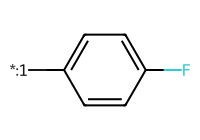
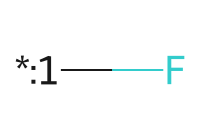
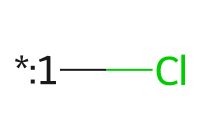
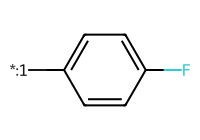
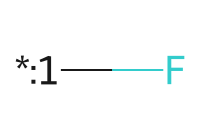
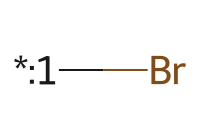
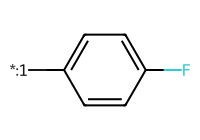
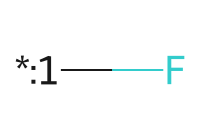
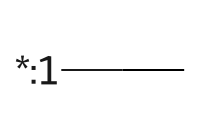
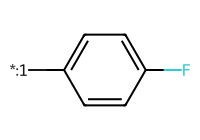
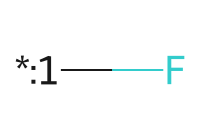
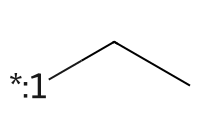
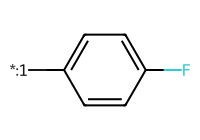
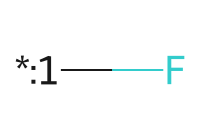
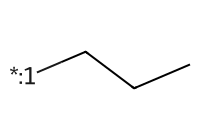
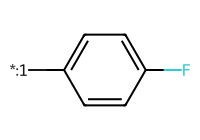
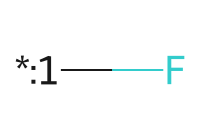
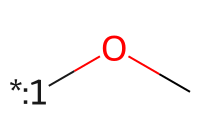
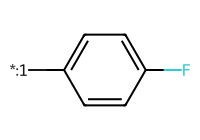
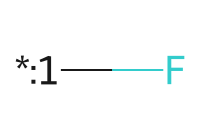
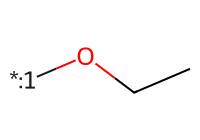
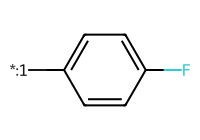
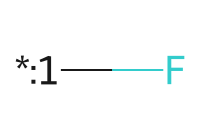
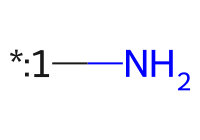
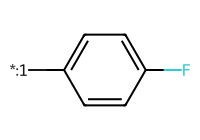
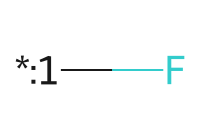
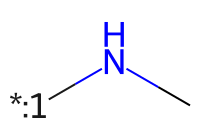
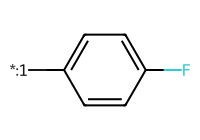
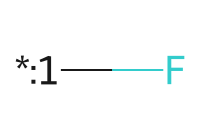
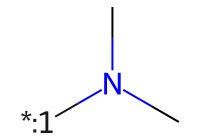
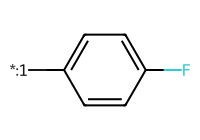
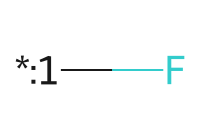
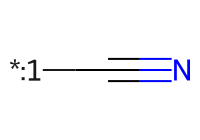
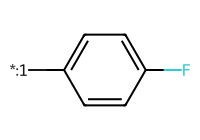
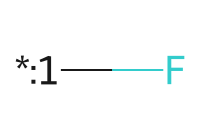
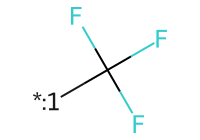
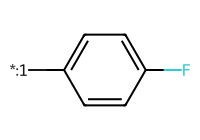
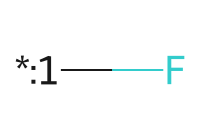
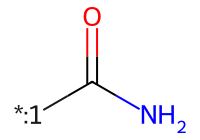
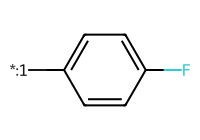
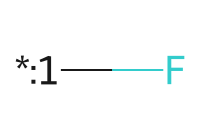
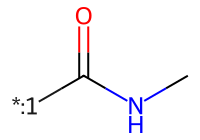
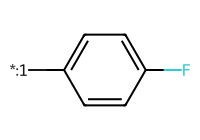
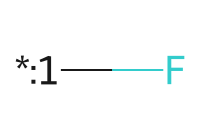
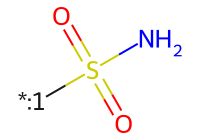

,compound_id,patent_id,assignees,pIC50_median,Core,R1,R2
0,DPC0001,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.750000,,,
1,DPC0002,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.885000,,,
2,DPC0003,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.790000,,,
3,DPC0004,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.620000,,,
4,DPC0005,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.630000,,,
5,DPC0006,DEMO-101-A1,Mosaic Medicines | Northstar Therapeutics,5.565000,,,
6,DPC0007,DEMO-101-A1,Northstar Therapeutics,5.350000,,,
7,DPC0008,DEMO-101-A1,Northstar Therapeutics,5.470000,,,
8,DPC0009,DEMO-101-A1,Northstar Therapeutics,5.480000,,,
9,DPC0010,DEMO-101-A1,Northstar Therapeutics,5.650000,,,

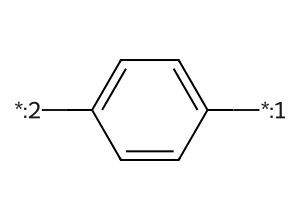
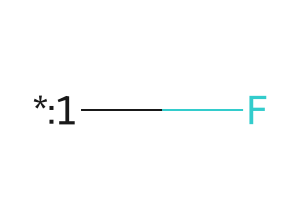
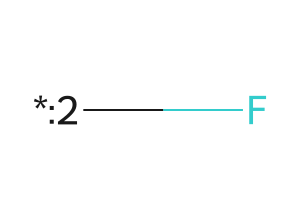
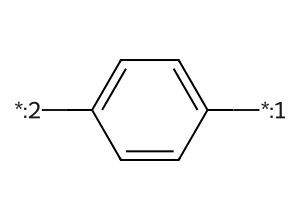
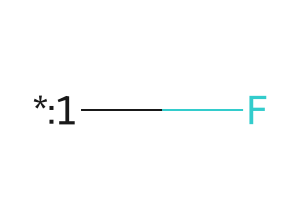
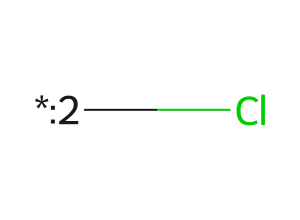
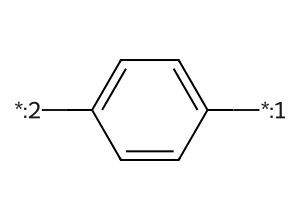
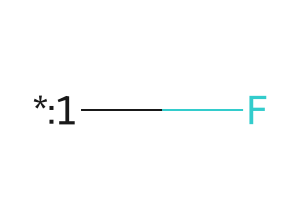
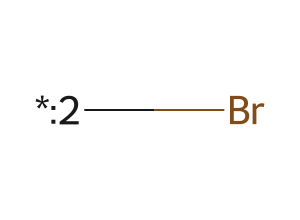
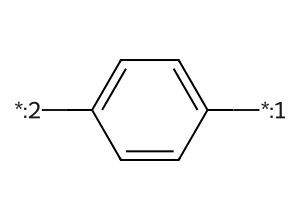
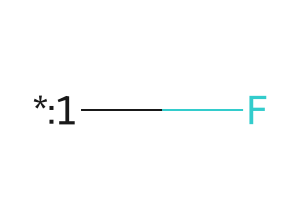
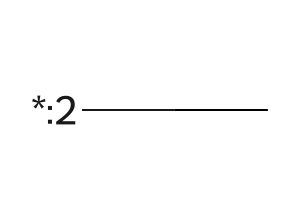
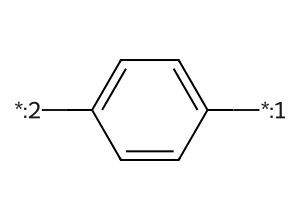
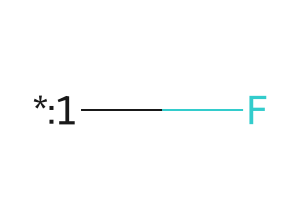
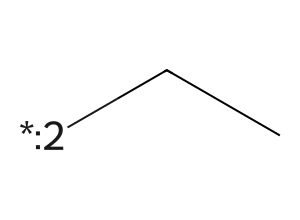
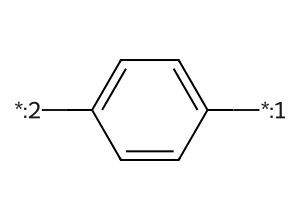
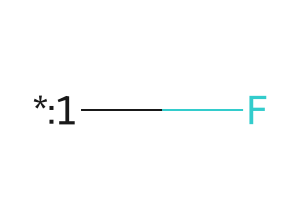
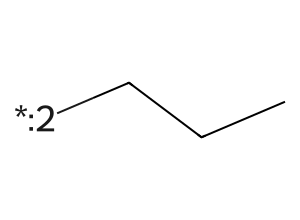
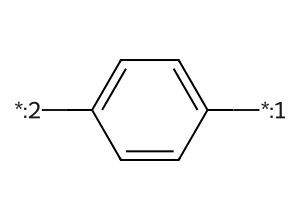
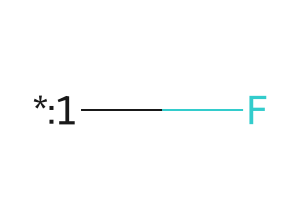
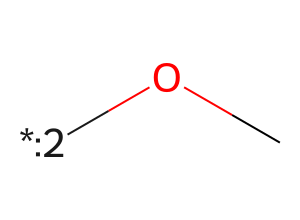
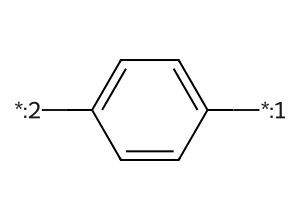
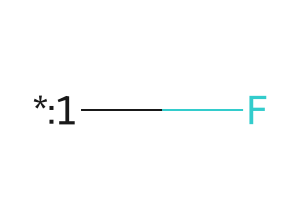
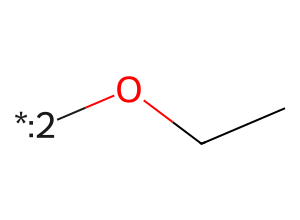
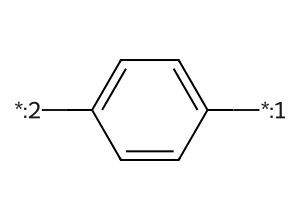
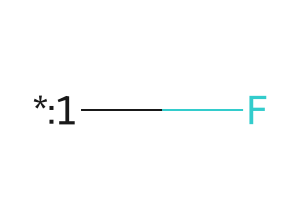
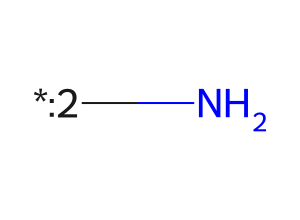
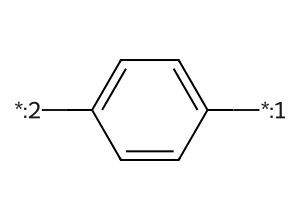
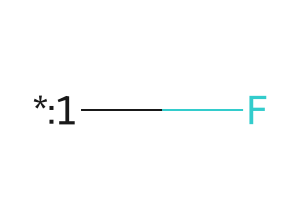
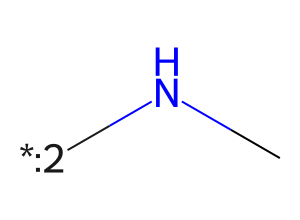
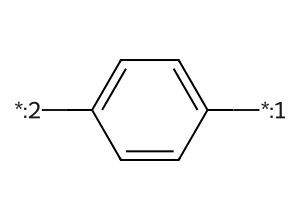
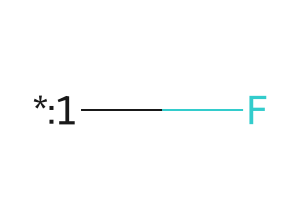
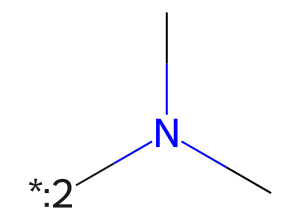
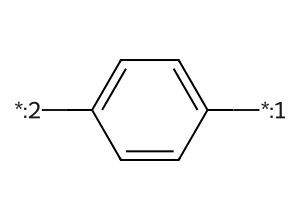
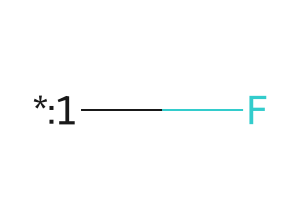
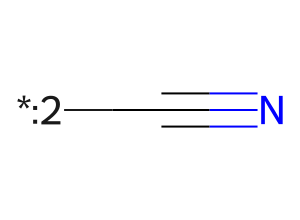
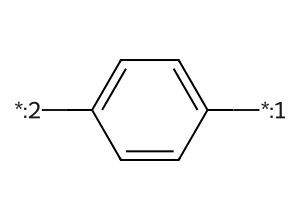
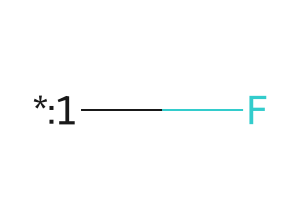
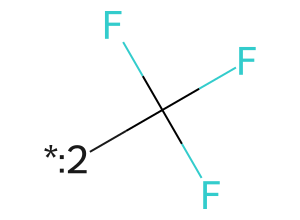
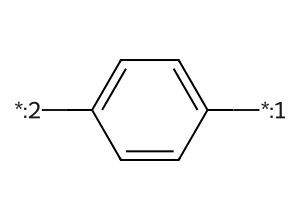
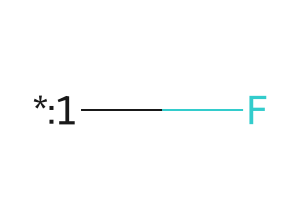
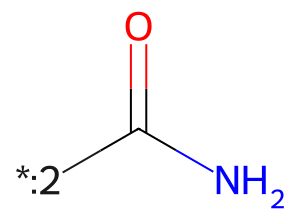
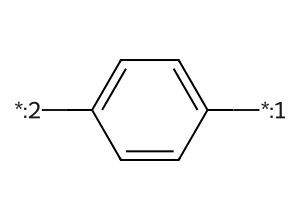
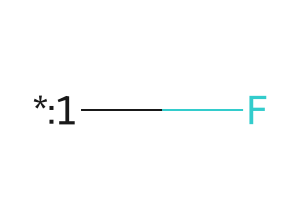
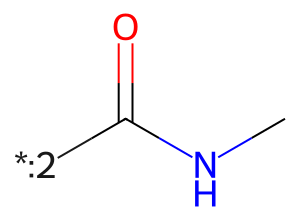

In [10]:
parser_params = rdmolfiles.SmilesParserParams()
parser_params.removeHs = False

def structure_cell(smiles, size=(200, 140)):
    if pd.isna(smiles) or not str(smiles).strip():
        return ''
    mol = Chem.MolFromSmiles(str(smiles), parser_params)
    if mol is None:
        return 'Invalid structure'
    buffer = BytesIO()
    Draw.MolToImage(mol, size=size).save(buffer, format='PNG')
    encoded = base64.b64encode(buffer.getvalue()).decode('ascii')
    return f'<img src="data:image/png;base64,{encoded}" width="{size[0]}">'

def is_hydrogen_r_group(smiles):
    if pd.isna(smiles) or not str(smiles).strip():
        return False
    mol = Chem.MolFromSmiles(str(smiles), parser_params)
    if mol is None:
        return False
    atoms = list(mol.GetAtoms())
    return any(atom.GetAtomicNum() == 1 for atom in atoms) and all(atom.GetAtomicNum() in (0, 1) for atom in atoms)

pairs = data['matched_pairs']
r_groups = data['r_group_table'].copy()
rg_cols = sorted((col for col in r_groups.columns if col.startswith('R') and col[1:].isdigit()), key=lambda col: int(col[1:]))
hydrogen_only = [col for col in rg_cols if not r_groups.empty and r_groups[col].map(is_hydrogen_r_group).all()]
r_groups = r_groups.drop(columns=hydrogen_only)
rg_cols = [col for col in rg_cols if col not in hydrogen_only]
r_groups = r_groups[[col for col in r_groups.columns if col not in rg_cols] + rg_cols]
print('Hydrogen-only R groups omitted:', hydrogen_only or 'none')
if not pairs.empty:
    pair_cols = [col for col in ('shared_core', 'fragment_a', 'fragment_b') if col in pairs.columns]
    display(pairs.head(15).style.format({col: structure_cell for col in pair_cols}, escape='html'))
if not r_groups.empty:
    structure_cols = (['Core'] if 'Core' in r_groups.columns else []) + rg_cols
    display(r_groups.head(15).style.format({col: lambda value: structure_cell(value, size=(300, 220)) for col in structure_cols}, escape='html'))
